In [1]:
import pandas as pd
import ast
import os

In [2]:
os.environ['R_HOME'] = '/home/ZHX/anaconda3/envs/GraphST/lib/R'
current_path = os.getcwd()
print("当前路径：", current_path)
file_path=current_path

当前路径： /home/ZHX/code111/GraphST-main/stMVCL/Tutorial


2、10X Visium 冠状小鼠切片cornal mouse brain数据集

/tmp/ipykernel_4169500/2997951405.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=models, y=ari_scores, palette='Set2')


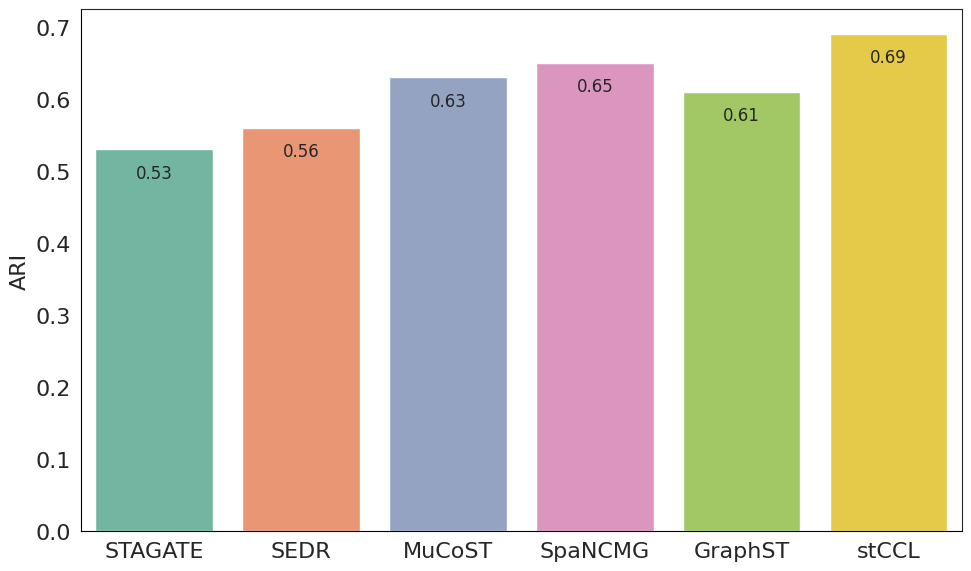

In [3]:
#绘制10X Visium 冠状小鼠切片cornal mouse brain数据集ARI柱状图
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os
import matplotlib as mpl
result_path = "/home/ZHX/code111/GraphST-main/final_result/result_visualization3/"
# 模型名称和对应的ARI分数（请替换为实际值）
models = ['STAGATE', 'SEDR', 'MuCoST', 'SpaNCMG', 'GraphST', 'stCCL']
ari_scores = [ 0.532, 0.558, 0.633, 0.648, 0.608, 0.693]  # 请替换为实际的ARI分数
nmi_scores = [ 0.713, 0.558, 0.760, 0.775, 0.741, 0.793]  # 请替换为实际的NMI分数

# 创建图像并设置大小
# 设置颜色和字体
sns.set_style("white")  # 设置背景为白色
colors = sns.color_palette(n_colors=6)
mpl.rcParams.update({'font.size': 16})
plt.figure(figsize=(10, 6))

# 绘制柱状图
ax = sns.barplot(x=models, y=ari_scores, palette='Set2')

# 添加标题和标签
# plt.title("Mean ARI Values for Each Method", fontsize=18)
plt.xlabel("")
plt.ylabel("ARI")

# 旋转 x 轴标签
# plt.xticks(rotation=45, ha='right')
ax.set_xlabel('', labelpad=50)
# 添加每个柱子的数值标签
for i, value in enumerate(ari_scores):
    ax.text(i, value - 0.02, f"{value:.2f}", ha='center', va='top', fontsize=12)

# 自动调整布局防止遮挡
plt.tight_layout()
# 设置边框样式
ax.spines['top'].set_visible(True)    # 移除上边框
ax.spines['right'].set_visible(True)  # 移除右边框
ax.spines['bottom'].set_visible(True)  # 保留下边框
ax.spines['left'].set_visible(True)    # 保留左边框

# 设置边框颜色为黑色
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

# 保存图像
plt.savefig(os.path.join(result_path, "cornal mouse brain_ARI_bar.png"), bbox_inches='tight')

# 显示图形
plt.show()


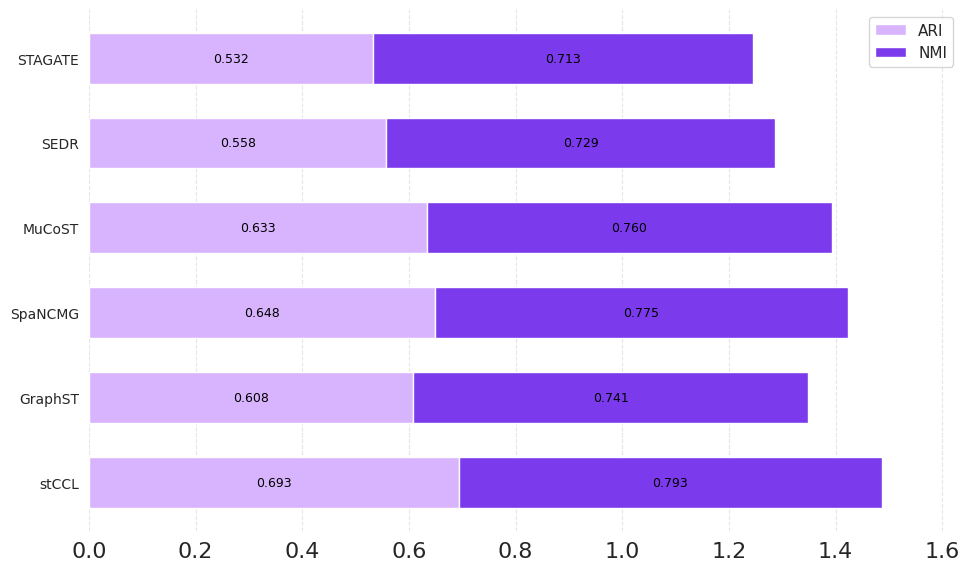

In [14]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import os
import matplotlib as mpl

# 设置结果保存路径
result_path = "/home/ZHX/code111/GraphST-main/final_result/result_visualization3/"
os.makedirs(result_path, exist_ok=True)

# 模型名称和对应的分数（请替换为实际值）
models = ['STAGATE', 'SEDR', 'MuCoST', 'SpaNCMG', 'GraphST', 'stCCL']
ari_scores = [0.532, 0.558, 0.633, 0.648, 0.608, 0.693]  # ARI
nmi_scores = [0.713, 0.729, 0.760, 0.775, 0.741, 0.793]  # NMI

# ==================== 绘制水平堆叠柱状图 ====================
sns.set_style("white")
mpl.rcParams.update({'font.size': 16})
fig, ax = plt.subplots(figsize=(10, 6))

# 纵坐标位置（方法索引）
y = np.arange(len(models))
height = 0.6  # 条的高度

# 绘制 ARI（左侧）和 NMI（右侧，堆叠在 ARI 之上）
bars_ari = ax.barh(y, ari_scores, height, label='ARI', color='#D8B4FE')
bars_nmi = ax.barh(y, nmi_scores, height, left=ari_scores, label='NMI', color='#7C3AED')

# 颠倒纵轴顺序：使第一个方法在底部，最后一个在顶部
ax.invert_yaxis()

# 在堆叠各部分内部添加数值标签（保留三位小数）
for i, (ari, nmi) in enumerate(zip(ari_scores, nmi_scores)):
    ax.text(ari/2, i, f'{ari:.3f}', ha='center', va='center', color='black', fontsize=9)
    ax.text(ari + nmi/2, i, f'{nmi:.3f}', ha='center', va='center', color='black', fontsize=9)

# 设置纵坐标刻度标签为方法名称
ax.set_yticks(y)
ax.set_yticklabels(models, fontsize=10)
# ax.set_xlabel('Score', fontsize=12)

# ---------- 去掉标题 ----------
# ax.set_title(...) 已删除

# ---------- 图例置于右上角 ----------
ax.legend(fontsize=11, loc='upper right')

# 横坐标刻度间隔为 0.2
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
max_total = max([ari + nmi for ari, nmi in zip(ari_scores, nmi_scores)])
xlim_max = max(max_total * 1.1, 1.0)
ax.set_xlim(0, xlim_max)

# 添加网格线（竖直线）
ax.grid(axis='x', linestyle='--', alpha=0.5)

# ---------- 去掉边框（所有边框不可见） ----------
for spine in ax.spines.values():
    spine.set_visible(False)

# 注意：去掉边框后，坐标轴刻度线也会消失（因为刻度线依附于spines），
# 若需要保留刻度线，可单独添加，但通常去掉边框后图表更简洁。
# 若希望保留x轴和y轴的轴线，可改为设置spine颜色为白色或隐藏特定边框，
# 但根据您“不要边框”的要求，此处全部隐藏。

plt.tight_layout()
plt.savefig(os.path.join(result_path, "cornal_mouse_brain_stacked_bar.png"), bbox_inches='tight', dpi=300)
plt.show()

3、10X Visium Mouse_anterior_brain 小鼠前脑数据集

/tmp/ipykernel_4169500/2383007123.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=models, y=ari_scores, palette='Set2')


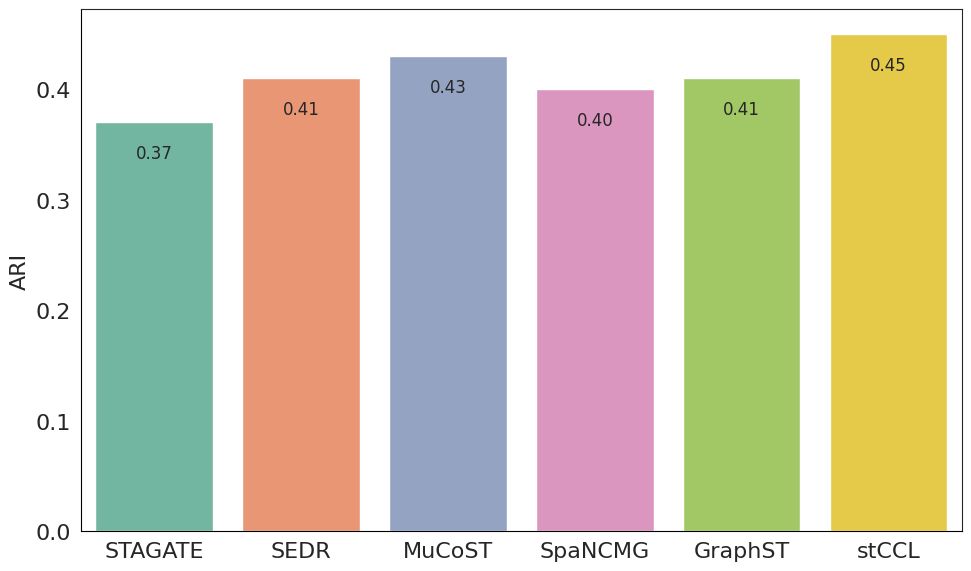

In [4]:
#绘制10X Visium Mouse_anterior_brain 小鼠前脑数据集ARI柱状图
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os
import matplotlib as mpl
result_path = "/home/ZHX/code111/GraphST-main/final_result/result_visualization2/"
# 模型名称和对应的ARI分数（请替换为实际值）
models = ['STAGATE', 'SEDR', 'MuCoST', 'SpaNCMG', 'GraphST', 'stCCL']
ari_scores = [0.37, 0.41, 0.43, 0.40, 0.41, 0.45]  # 请替换为实际的ARI分数

# 创建图像并设置大小
# 设置颜色和字体
sns.set_style("white")  # 设置背景为白色
colors = sns.color_palette(n_colors=7)
mpl.rcParams.update({'font.size': 16})
plt.figure(figsize=(10, 6))

# 绘制柱状图
ax = sns.barplot(x=models, y=ari_scores, palette='Set2')

# 添加标题和标签
# plt.title("Mean ARI Values for Each Method", fontsize=18)
plt.xlabel("")
plt.ylabel("ARI")

# 旋转 x 轴标签
# plt.xticks(rotation=45, ha='right')
ax.set_xlabel('', labelpad=50)
# 添加每个柱子的数值标签
for i, value in enumerate(ari_scores):
    ax.text(i, value - 0.02, f"{value:.2f}", ha='center', va='top', fontsize=12)

# 自动调整布局防止遮挡
plt.tight_layout()
# 设置边框样式
ax.spines['top'].set_visible(True)    # 移除上边框
ax.spines['right'].set_visible(True)  # 移除右边框
ax.spines['bottom'].set_visible(True)  # 保留下边框
ax.spines['left'].set_visible(True)    # 保留左边框

# 设置边框颜色为黑色
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

# 保存图像
plt.savefig(os.path.join(result_path, "MA_ARI_bar.png"), bbox_inches='tight')

# 显示图形
plt.show()


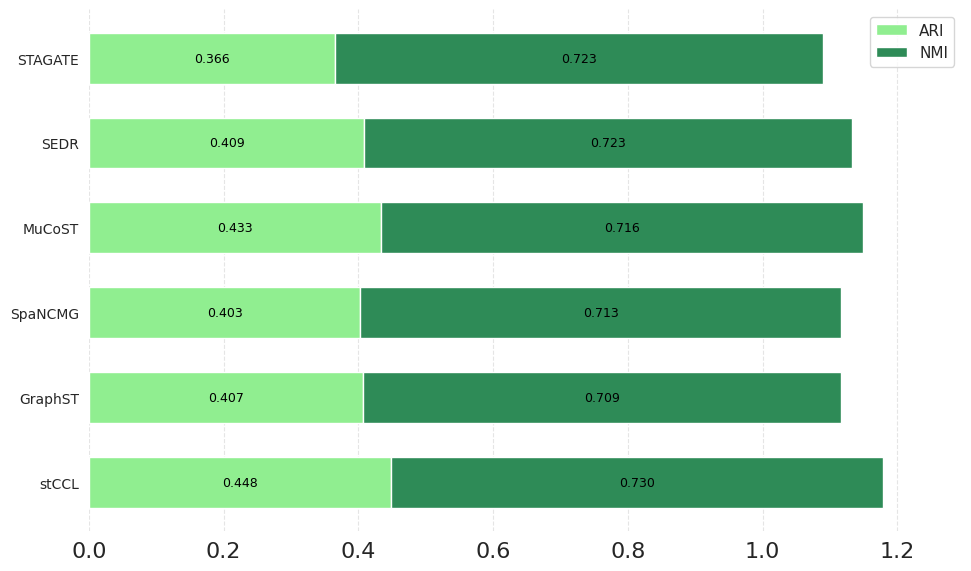

In [15]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import os
import matplotlib as mpl

# 设置结果保存路径
result_path = "/home/ZHX/code111/GraphST-main/final_result/result_visualization3/"
os.makedirs(result_path, exist_ok=True)

# 模型名称和对应的分数（请替换为实际值）
models = ['STAGATE', 'SEDR', 'MuCoST', 'SpaNCMG', 'GraphST', 'stCCL']
ari_scores = [0.366, 0.409, 0.433, 0.403, 0.407, 0.448]  # ARI
nmi_scores = [0.723, 0.723, 0.716, 0.713, 0.709, 0.730]  # NMI

# ==================== 绘制水平堆叠柱状图 ====================
sns.set_style("white")
mpl.rcParams.update({'font.size': 16})
fig, ax = plt.subplots(figsize=(10, 6))

# 纵坐标位置（方法索引）
y = np.arange(len(models))
height = 0.6  # 条的高度

# 绘制 ARI（左侧）和 NMI（右侧，堆叠在 ARI 之上）
bars_ari = ax.barh(y, ari_scores, height, label='ARI', color='lightgreen')
bars_nmi = ax.barh(y, nmi_scores, height, left=ari_scores, label='NMI', color='#2E8B57')

# 颠倒纵轴顺序：使第一个方法在底部，最后一个在顶部
ax.invert_yaxis()

# 在堆叠各部分内部添加数值标签（保留三位小数）
for i, (ari, nmi) in enumerate(zip(ari_scores, nmi_scores)):
    ax.text(ari/2, i, f'{ari:.3f}', ha='center', va='center', color='black', fontsize=9)
    ax.text(ari + nmi/2, i, f'{nmi:.3f}', ha='center', va='center', color='black', fontsize=9)

# 设置纵坐标刻度标签为方法名称
ax.set_yticks(y)
ax.set_yticklabels(models, fontsize=10)
# ax.set_xlabel('Score', fontsize=12)

# ---------- 去掉标题 ----------
# ax.set_title(...) 已删除

# ---------- 图例置于右上角 ----------
ax.legend(fontsize=11, loc='upper right')

# 横坐标刻度间隔为 0.2
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
max_total = max([ari + nmi for ari, nmi in zip(ari_scores, nmi_scores)])
xlim_max = max(max_total * 1.1, 1.0)
ax.set_xlim(0, xlim_max)

# 添加网格线（竖直线）
ax.grid(axis='x', linestyle='--', alpha=0.5)

# ---------- 去掉边框（所有边框不可见） ----------
for spine in ax.spines.values():
    spine.set_visible(False)

# 注意：去掉边框后，坐标轴刻度线也会消失（因为刻度线依附于spines），
# 若需要保留刻度线，可单独添加，但通常去掉边框后图表更简洁。
# 若希望保留x轴和y轴的轴线，可改为设置spine颜色为白色或隐藏特定边框，
# 但根据您“不要边框”的要求，此处全部隐藏。

plt.tight_layout()
plt.savefig(os.path.join(result_path, "MA_stacked_bar.png"), bbox_inches='tight', dpi=300)
plt.show()

4、osmFISH SScortex mouse 小鼠体感皮层（osmFISH）数据集

/tmp/ipykernel_4169500/2732921914.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=models, y=ari_scores, palette='Set2')


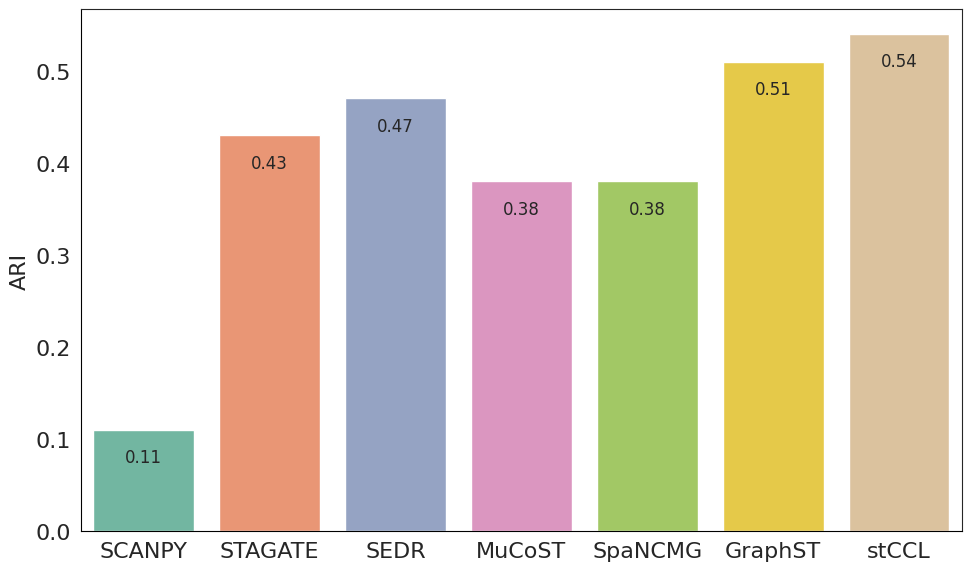

In [5]:
#绘制1osmFISH SScortex mouse 小鼠体感皮层（osmFISH）数据集ARI柱状图
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os
import matplotlib as mpl
result_path = "/home/ZHX/code111/GraphST-main/final_result/result_visualization2/"
# 模型名称和对应的ARI分数（请替换为实际值）
models = ['SCANPY', 'STAGATE', 'SEDR', 'MuCoST', 'SpaNCMG', 'GraphST', 'stCCL']
ari_scores = [0.11, 0.43, 0.47, 0.38, 0.38, 0.51, 0.54]  # 请替换为实际的ARI分数

# 创建图像并设置大小
# 设置颜色和字体
sns.set_style("white")  # 设置背景为白色
colors = sns.color_palette(n_colors=7)
mpl.rcParams.update({'font.size': 16})
plt.figure(figsize=(10, 6))

# 绘制柱状图
ax = sns.barplot(x=models, y=ari_scores, palette='Set2')

# 添加标题和标签
# plt.title("Mean ARI Values for Each Method", fontsize=18)
plt.xlabel("")
plt.ylabel("ARI")

# 旋转 x 轴标签
# plt.xticks(rotation=45, ha='right')
ax.set_xlabel('', labelpad=50)
# 添加每个柱子的数值标签
for i, value in enumerate(ari_scores):
    ax.text(i, value - 0.02, f"{value:.2f}", ha='center', va='top', fontsize=12)

# 自动调整布局防止遮挡
plt.tight_layout()
# 设置边框样式
ax.spines['top'].set_visible(True)    # 移除上边框
ax.spines['right'].set_visible(True)  # 移除右边框
ax.spines['bottom'].set_visible(True)  # 保留下边框
ax.spines['left'].set_visible(True)    # 保留左边框

# 设置边框颜色为黑色
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

# 保存图像
plt.savefig(os.path.join(result_path, "osmFISH_ARI_bar.png"), bbox_inches='tight')

# 显示图形
plt.show()


消融实验

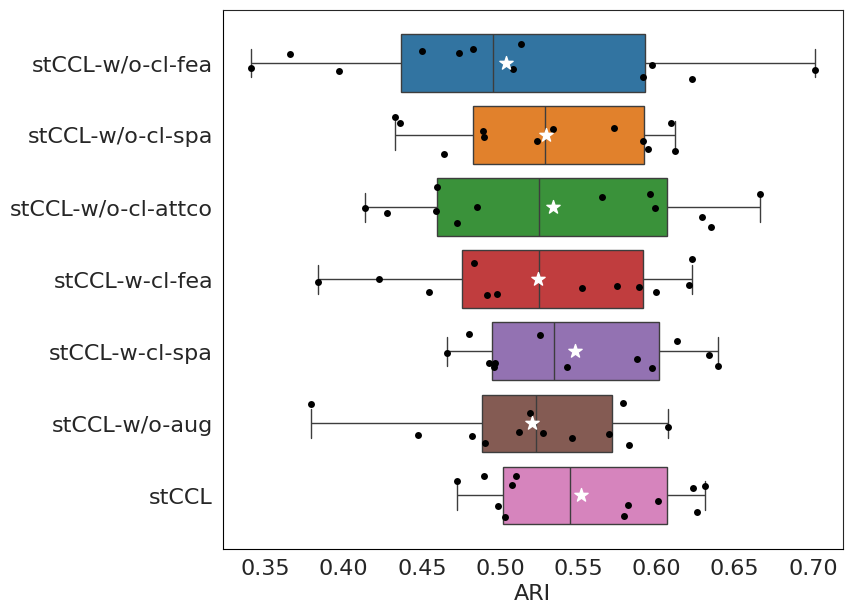

In [1]:
#消融实验ARI的水平箱线图和散点图
import os
import pandas as pd
import matplotlib.pyplot as plt
import xlrd
import seaborn as sns
import matplotlib as mpl
sns.set_style("white")  # 设置背景为白色
colors = sns.color_palette(n_colors=7)
mpl.rcParams.update({'font.size': 16})
plt.figure(figsize=(8, 7))

result_path = "/home/ZHX/code111/GraphST-main/final_result/result_visualization2/"
df = pd.read_excel('/home/ZHX/code111/GraphST-main/final_result/DLPFC_ablation2.xlsx', engine='openpyxl',index_col=0)  # 指定引擎为openpyxl以处理.xlsx文件


ax = sns.boxplot(data=df, orient='h')
ax = sns.stripplot(data=df,orient='h',color='black' ,jitter=0.3, size=5)
mean = df.mean()
ax.set_ylabel('',rotation=0, labelpad=50, va='center')
for i, val in enumerate(mean):
    ax.scatter(val, i, color='white', s=100, marker='*',zorder=10, label=f'Mean {df.columns[i]}')
# 倒序 y 轴
# ax.invert_yaxis()
# ax.set_title("DLPFC")
plt.xlabel("ARI")
# 设置边框样式
ax.spines['top'].set_visible(True)    # 移除上边框
ax.spines['right'].set_visible(True)  # 移除右边框
ax.spines['bottom'].set_visible(True)  # 保留下边框
ax.spines['left'].set_visible(True)    # 保留左边框

# 设置边框颜色为黑色
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

# 移除网格线（内框线）
ax.grid(False)

plt.savefig(os.path.join(result_path,"DLPFC_ablation_ARI_h_box_strip.png"))

plt.show()


/tmp/ipykernel_4169500/1190872266.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=models, y=ari_scores, palette='Set2')


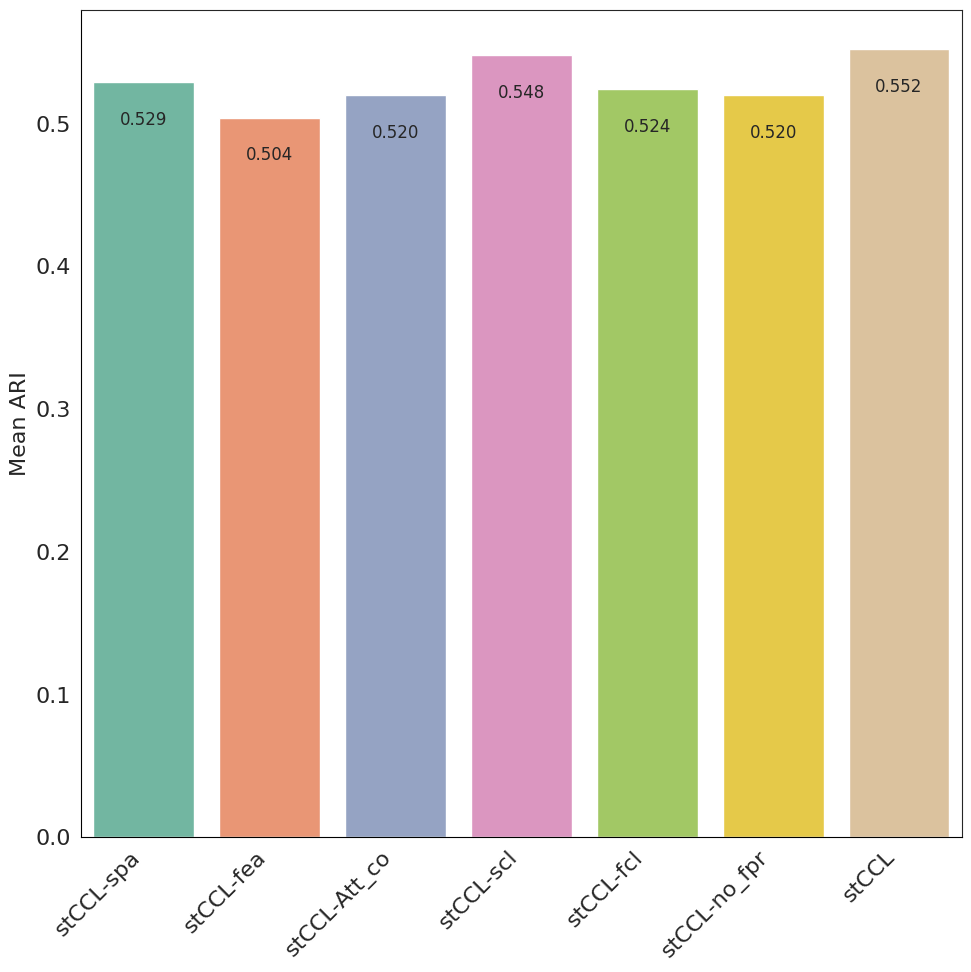

In [8]:
#绘制1osmFISH SScortex mouse 小鼠体感皮层（osmFISH）数据集ARI柱状图
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os
import matplotlib as mpl
result_path = "/home/ZHX/code111/GraphST-main/final_result/result_visualization/"
# 模型名称和对应的ARI分数（请替换为实际值）
models = ['stCCL-spa', 'stCCL-fea', 'stCCL-Att_co', 'stCCL-scl', 'stCCL-fcl', 'stCCL-no_fpr','stCCL']
ari_scores = [0.529, 0.504, 0.520, 0.548, 0.524, 0.520, 0.552]  # 请替换为实际的ARI分数

# 创建图像并设置大小
# 设置颜色和字体
sns.set_style("white")  # 设置背景为白色
colors = sns.color_palette(n_colors=7)
mpl.rcParams.update({'font.size': 16})
plt.figure(figsize=(10, 10))

# 绘制柱状图
ax = sns.barplot(x=models, y=ari_scores, palette='Set2')

# 添加标题和标签
# plt.title("Mean ARI Values for Each Method", fontsize=18)
plt.xlabel("")
plt.ylabel("Mean ARI")

# 旋转 x 轴标签
plt.xticks(rotation=45, ha='right')
ax.set_xlabel('', labelpad=50)
# 添加每个柱子的数值标签
for i, value in enumerate(ari_scores):
    ax.text(i, value - 0.02, f"{value:.3f}", ha='center', va='top', fontsize=12)

# 自动调整布局防止遮挡
plt.tight_layout()
# 设置边框样式
ax.spines['top'].set_visible(True)    # 移除上边框
ax.spines['right'].set_visible(True)  # 移除右边框
ax.spines['bottom'].set_visible(True)  # 保留下边框
ax.spines['left'].set_visible(True)    # 保留左边框

# 设置边框颜色为黑色
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

# 保存图像
plt.savefig(os.path.join(result_path, "DLPFC_ablation_ARI_bar.png"), bbox_inches='tight')

# 显示图形
plt.show()


/tmp/ipykernel_4169500/1264474113.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=models, y=ari_scores, palette='Set2')


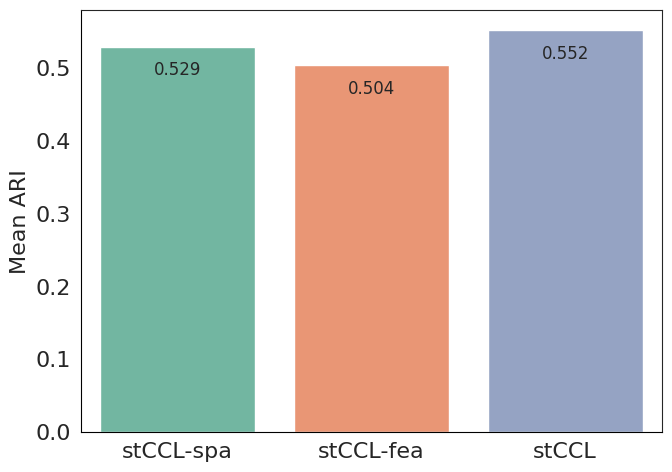

In [9]:
#绘制1osmFISH SScortex mouse 小鼠体感皮层（osmFISH）数据集ARI柱状图
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os
import matplotlib as mpl
result_path = "/home/ZHX/code111/GraphST-main/final_result/result_visualization/"
# 模型名称和对应的ARI分数（请替换为实际值）
models = ['stCCL-spa', 'stCCL-fea',  'stCCL']
ari_scores = [0.529, 0.504,  0.552]  # 请替换为实际的ARI分数

# 创建图像并设置大小
# 设置颜色和字体
sns.set_style("white")  # 设置背景为白色
colors = sns.color_palette(n_colors=7)
mpl.rcParams.update({'font.size': 16})
plt.figure(figsize=(7, 5))

# 绘制柱状图
ax = sns.barplot(x=models, y=ari_scores, palette='Set2')

# 添加标题和标签
# plt.title("Mean ARI Values for Each Method", fontsize=18)
plt.xlabel("")
plt.ylabel("Mean ARI")

# 旋转 x 轴标签
# plt.xticks(rotation=45, ha='right')
ax.set_xlabel('', labelpad=50)
# 添加每个柱子的数值标签
for i, value in enumerate(ari_scores):
    ax.text(i, value - 0.02, f"{value:.3f}", ha='center', va='top', fontsize=12)

# 自动调整布局防止遮挡
plt.tight_layout()
# 设置边框样式
ax.spines['top'].set_visible(True)    # 移除上边框
ax.spines['right'].set_visible(True)  # 移除右边框
ax.spines['bottom'].set_visible(True)  # 保留下边框
ax.spines['left'].set_visible(True)    # 保留左边框

# 设置边框颜色为黑色
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

# 保存图像
plt.savefig(os.path.join(result_path, "DLPFC_ablation_ARI_bar2.png"), bbox_inches='tight')

# 显示图形
plt.show()


参数设置实验

图片已保存至：/home/ZHX/code111/GraphST-main/final_result/result_visualization/beta_sensitivity_ARI.png


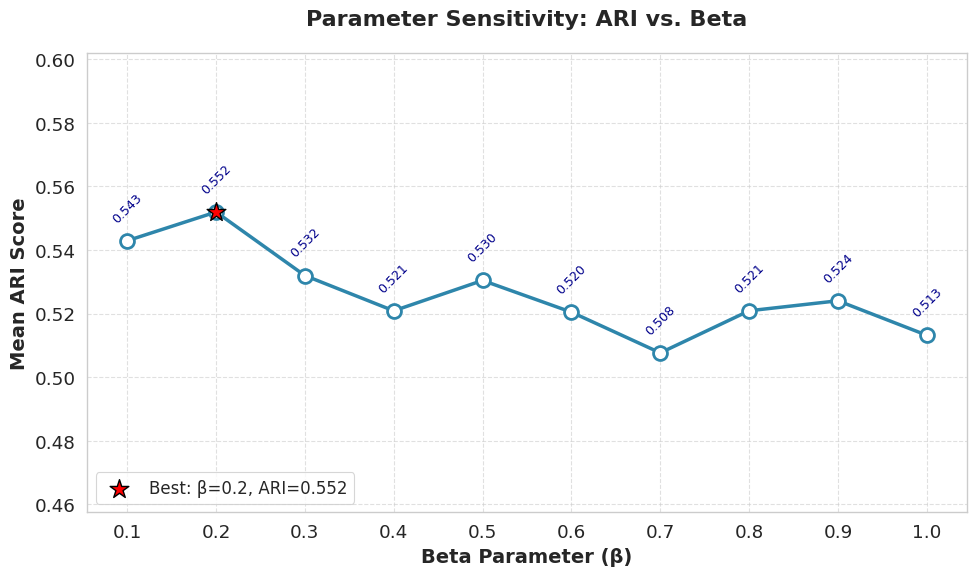

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# 设置结果保存路径
result_path = "/home/ZHX/code111/GraphST-main/final_result/result_visualization/"
os.makedirs(result_path, exist_ok=True)

# 参数范围：0.1 到 1.0，步长 0.1
beta_values = np.arange(0.1, 1.1, 0.1)  # [0.1, 0.2, ..., 1.0]

# 对应的 ARI 分数（请按顺序对应）
ari_scores = [0.542908074, 0.551935431, 0.531957454, 0.520872662, 0.530425551,
              0.520453481, 0.507650407, 0.520888439, 0.524034274, 0.513192276]
nmi_scores = [0.672098292, 0.679869648, 0.674507876, 0.654261392, 0.669948002,
              0.661891321, 0.651938246, 0.665014792, 0.66649981, 0.654670151]

# 设置 Seaborn 风格
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.5)

# 创建画布
plt.figure(figsize=(10, 6))

# 绘制折线图，带圆形标记
plt.plot(beta_values, ari_scores, marker='o', markersize=10,
         linestyle='-', linewidth=2.5, color='#2E86AB',
         markerfacecolor='white', markeredgewidth=2, markeredgecolor='#2E86AB')

# 找出最高点
best_idx = np.argmax(ari_scores)
best_beta = beta_values[best_idx]
best_ari = ari_scores[best_idx]

# 标记最高点（红色五角星）
plt.scatter(best_beta, best_ari, color='red', s=200, marker='*',
            edgecolor='black', linewidth=1, zorder=5, label=f'Best: β={best_beta:.1f}, ARI={best_ari:.3f}')

# 添加数值标签（在每个点上方显示 ARI 值）
for i, (beta, ari) in enumerate(zip(beta_values, ari_scores)):
    plt.text(beta, ari + 0.005, f'{ari:.3f}', ha='center', va='bottom',
             fontsize=9, rotation=45, color='darkblue')

# 图表标题和轴标签
plt.xlabel('Beta Parameter (β)', fontsize=14, fontweight='bold')
plt.ylabel('Mean ARI Score', fontsize=14, fontweight='bold')
plt.title('Parameter Sensitivity: ARI vs. Beta', fontsize=16, fontweight='bold', pad=20)

# 设置横轴刻度（显示所有 beta 值）
plt.xticks(beta_values, [f'{b:.1f}' for b in beta_values])

# 添加图例
plt.legend(loc='lower left', fontsize=12, frameon=True)

# 调整 y 轴范围，留出数值标签空间
plt.ylim(min(ari_scores) - 0.05, max(ari_scores) + 0.05)

# 添加轻微网格
plt.grid(True, linestyle='--', alpha=0.6)

# 紧凑布局
plt.tight_layout()

# 保存图片（高分辨率）
save_path = os.path.join(result_path, 'beta_sensitivity_ARI.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"图片已保存至：{save_path}")

# 显示（如在 Jupyter 或交互环境中）
plt.show()

图片已保存至：/home/ZHX/code111/GraphST-main/final_result/result_visualization/alpha_sensitivity_ARI_NMI.png


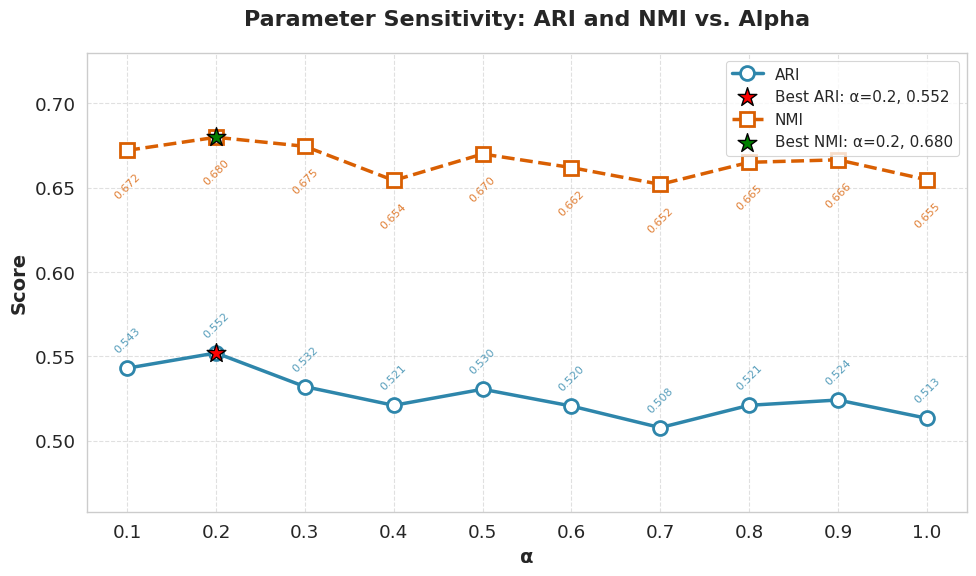

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# 设置结果保存路径
result_path = "/home/ZHX/code111/GraphST-main/final_result/result_visualization/"
os.makedirs(result_path, exist_ok=True)

# 参数范围：0.1 到 1.0，步长 0.1
beta_values = np.arange(0.1, 1.1, 0.1)

# ARI 和 NMI 分数
ari_scores = [0.542908074, 0.551935431, 0.531957454, 0.520872662, 0.530425551,
              0.520453481, 0.507650407, 0.520888439, 0.524034274, 0.513192276]
nmi_scores = [0.672098292, 0.679869648, 0.674507876, 0.654261392, 0.669948002,
              0.661891321, 0.651938246, 0.665014792, 0.66649981, 0.654670151]

# 设置 Seaborn 风格
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.5)

# 创建画布
plt.figure(figsize=(10, 6))

# ========== 绘制 ARI 折线 ==========
plt.plot(beta_values, ari_scores, marker='o', markersize=10,
         linestyle='-', linewidth=2.5, color='#2E86AB',
         markerfacecolor='white', markeredgewidth=2, markeredgecolor='#2E86AB',
         label='ARI')

# ARI 最高点
best_ari_idx = np.argmax(ari_scores)
best_ari_beta = beta_values[best_ari_idx]
best_ari = ari_scores[best_ari_idx]
plt.scatter(best_ari_beta, best_ari, color='red', s=200, marker='*',
            edgecolor='black', linewidth=1, zorder=5,
            label=f'Best ARI: α={best_ari_beta:.1f}, {best_ari:.3f}')

# ARI 数值标签（错开位置，避免重叠）
for i, (beta, ari) in enumerate(zip(beta_values, ari_scores)):
    plt.text(beta, ari + 0.008, f'{ari:.3f}', ha='center', va='bottom',
             fontsize=8, rotation=45, color='#2E86AB', alpha=0.8)

# ========== 绘制 NMI 折线 ==========
plt.plot(beta_values, nmi_scores, marker='s', markersize=10,
         linestyle='--', linewidth=2.5, color='#D95F02',
         markerfacecolor='white', markeredgewidth=2, markeredgecolor='#D95F02',
         label='NMI')

# NMI 最高点
best_nmi_idx = np.argmax(nmi_scores)
best_nmi_beta = beta_values[best_nmi_idx]
best_nmi = nmi_scores[best_nmi_idx]
plt.scatter(best_nmi_beta, best_nmi, color='green', s=200, marker='*',
            edgecolor='black', linewidth=1, zorder=5,
            label=f'Best NMI: α={best_nmi_beta:.1f}, {best_nmi:.3f}')

# NMI 数值标签（略微下移，避免与 ARI 标签重叠）
for i, (beta, nmi) in enumerate(zip(beta_values, nmi_scores)):
    plt.text(beta, nmi - 0.012, f'{nmi:.3f}', ha='center', va='top',
             fontsize=8, rotation=45, color='#D95F02', alpha=0.8)

# ========== 图表设置 ==========
plt.xlabel('α', fontsize=14, fontweight='bold')
plt.ylabel('Score', fontsize=14, fontweight='bold')
plt.title('Parameter Sensitivity: ARI and NMI vs. Alpha', fontsize=16, fontweight='bold', pad=20)

plt.xticks(beta_values, [f'{b:.1f}' for b in beta_values])

# 图例（放在左上角，避免遮挡数据）
plt.legend(loc='upper right', fontsize=11, frameon=True)

# y 轴范围（统一留出空间）
y_min = min(min(ari_scores), min(nmi_scores)) - 0.05
y_max = max(max(ari_scores), max(nmi_scores)) + 0.05
plt.ylim(y_min, y_max)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# 保存图片
save_path = os.path.join(result_path, 'alpha_sensitivity_ARI_NMI.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"图片已保存至：{save_path}")

plt.show()

图片已保存至：/home/ZHX/code111/GraphST-main/final_result/result_visualization/k_sensitivity_ARI_NMI.png


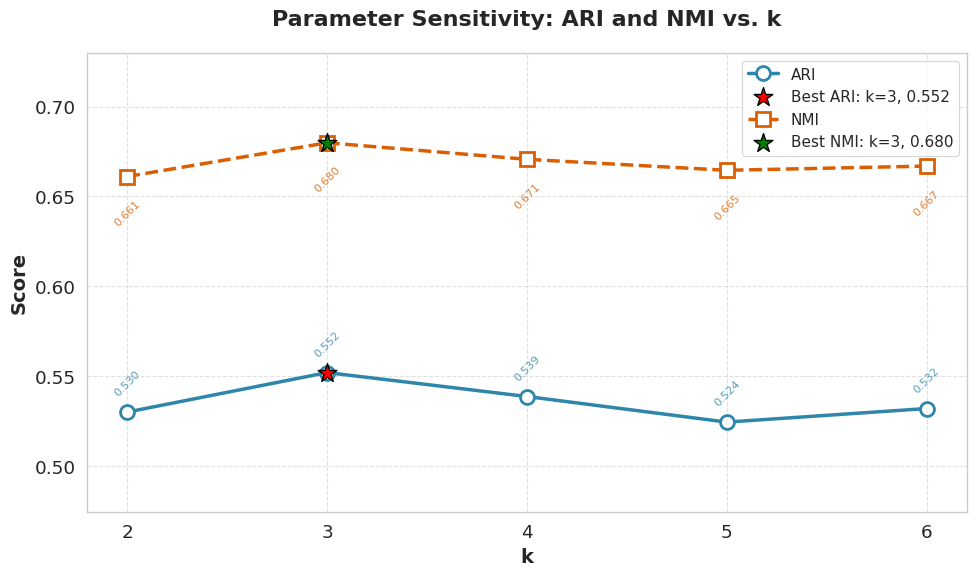

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# 设置结果保存路径
result_path = "/home/ZHX/code111/GraphST-main/final_result/result_visualization/"
os.makedirs(result_path, exist_ok=True)

# 参数范围：2 到 6，步长 1
k_values = np.arange(2, 7, 1)  # [2, 3, 4, 5, 6]

# ARI 和 NMI 分数（对应 k = 2,3,4,5,6）
ari_scores = [0.529938548, 0.551935431, 0.53860436, 0.52435818, 0.531928641]
nmi_scores = [0.661084099, 0.679869648, 0.670671319, 0.664548992, 0.666900703]

# 设置 Seaborn 风格
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.5)

# 创建画布
plt.figure(figsize=(10, 6))

# ========== 绘制 ARI 折线 ==========
plt.plot(k_values, ari_scores, marker='o', markersize=10,
         linestyle='-', linewidth=2.5, color='#2E86AB',
         markerfacecolor='white', markeredgewidth=2, markeredgecolor='#2E86AB',
         label='ARI')

# ARI 最高点
best_ari_idx = np.argmax(ari_scores)
best_ari_k = k_values[best_ari_idx]
best_ari = ari_scores[best_ari_idx]
plt.scatter(best_ari_k, best_ari, color='red', s=200, marker='*',
            edgecolor='black', linewidth=1, zorder=5,
            label=f'Best ARI: k={best_ari_k:.0f}, {best_ari:.3f}')

# ARI 数值标签（显示在点上方）
for i, (k, ari) in enumerate(zip(k_values, ari_scores)):
    plt.text(k, ari + 0.008, f'{ari:.3f}', ha='center', va='bottom',
             fontsize=8, rotation=45, color='#2E86AB', alpha=0.8)

# ========== 绘制 NMI 折线 ==========
plt.plot(k_values, nmi_scores, marker='s', markersize=10,
         linestyle='--', linewidth=2.5, color='#D95F02',
         markerfacecolor='white', markeredgewidth=2, markeredgecolor='#D95F02',
         label='NMI')

# NMI 最高点
best_nmi_idx = np.argmax(nmi_scores)
best_nmi_k = k_values[best_nmi_idx]
best_nmi = nmi_scores[best_nmi_idx]
plt.scatter(best_nmi_k, best_nmi, color='green', s=200, marker='*',
            edgecolor='black', linewidth=1, zorder=5,
            label=f'Best NMI: k={best_nmi_k:.0f}, {best_nmi:.3f}')

# NMI 数值标签（显示在点下方，避免与 ARI 标签重叠）
for i, (k, nmi) in enumerate(zip(k_values, nmi_scores)):
    plt.text(k, nmi - 0.012, f'{nmi:.3f}', ha='center', va='top',
             fontsize=8, rotation=45, color='#D95F02', alpha=0.8)

# ========== 图表设置 ==========
plt.xlabel('k', fontsize=14, fontweight='bold')
plt.ylabel('Score', fontsize=14, fontweight='bold')
plt.title('Parameter Sensitivity: ARI and NMI vs. k', fontsize=16, fontweight='bold', pad=20)

plt.xticks(k_values, [f'{k:.0f}' for k in k_values])

# 图例（放在右上角）
plt.legend(loc='upper right', fontsize=11, frameon=True)

# y 轴范围（统一留出空间）
y_min = min(min(ari_scores), min(nmi_scores)) - 0.05
y_max = max(max(ari_scores), max(nmi_scores)) + 0.05
plt.ylim(y_min, y_max)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# 保存图片
save_path = os.path.join(result_path, 'k_sensitivity_ARI_NMI.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"图片已保存至：{save_path}")

plt.show()

图片已保存至：/home/ZHX/code111/GraphST-main/final_result/result_visualization/radius_sensitivity_ARI_NMI.png


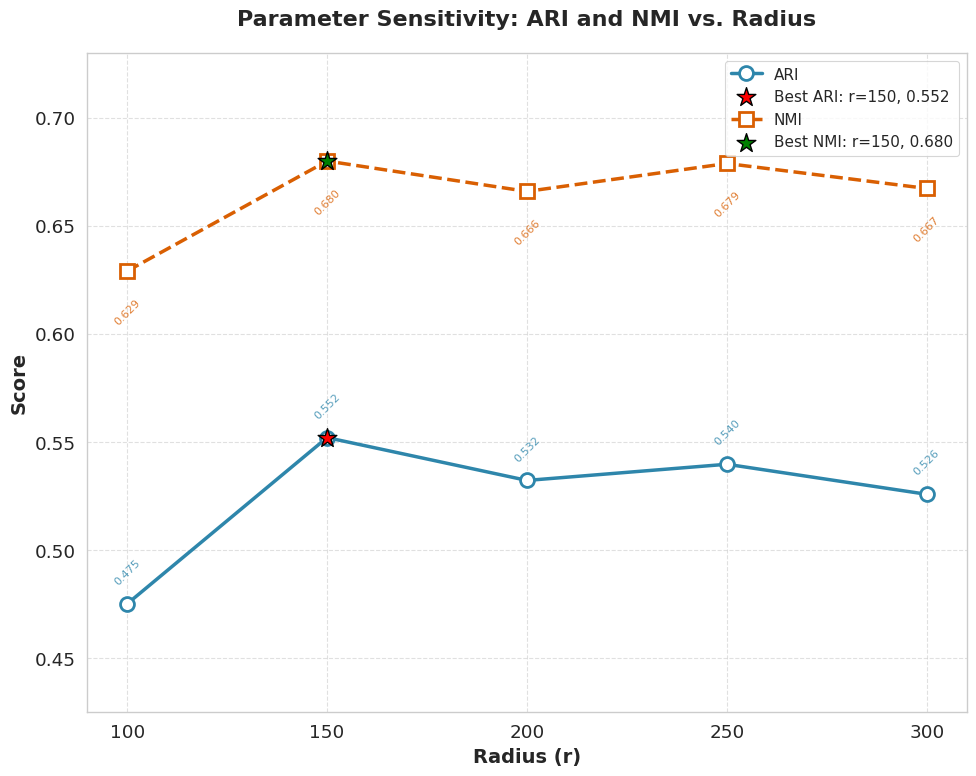

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# 设置结果保存路径
result_path = "/home/ZHX/code111/GraphST-main/final_result/result_visualization/"
os.makedirs(result_path, exist_ok=True)

# 参数范围：100 到 300，步长 50（共 5 个值：100, 150, 200, 250, 300）
radius_values = np.arange(100, 350, 50)  # [100, 150, 200, 250, 300]

# ARI 和 NMI 分数（对应 radius = 100, 150, 200, 250, 300）
ari_scores = [0.47501393, 0.551935431, 0.532110272, 0.539594443, 0.525688725]
nmi_scores = [0.628990691, 0.679869648, 0.665825523, 0.678737362, 0.667184317]

# 设置 Seaborn 风格
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.5)

# 创建画布
plt.figure(figsize=(10, 8))

# ========== 绘制 ARI 折线 ==========
plt.plot(radius_values, ari_scores, marker='o', markersize=10,
         linestyle='-', linewidth=2.5, color='#2E86AB',
         markerfacecolor='white', markeredgewidth=2, markeredgecolor='#2E86AB',
         label='ARI')

# ARI 最高点
best_ari_idx = np.argmax(ari_scores)
best_ari_r = radius_values[best_ari_idx]
best_ari = ari_scores[best_ari_idx]
plt.scatter(best_ari_r, best_ari, color='red', s=200, marker='*',
            edgecolor='black', linewidth=1, zorder=5,
            label=f'Best ARI: r={best_ari_r:.0f}, {best_ari:.3f}')

# ARI 数值标签（显示在点上方）
for i, (r, ari) in enumerate(zip(radius_values, ari_scores)):
    plt.text(r, ari + 0.008, f'{ari:.3f}', ha='center', va='bottom',
             fontsize=8, rotation=45, color='#2E86AB', alpha=0.8)

# ========== 绘制 NMI 折线 ==========
plt.plot(radius_values, nmi_scores, marker='s', markersize=10,
         linestyle='--', linewidth=2.5, color='#D95F02',
         markerfacecolor='white', markeredgewidth=2, markeredgecolor='#D95F02',
         label='NMI')

# NMI 最高点
best_nmi_idx = np.argmax(nmi_scores)
best_nmi_r = radius_values[best_nmi_idx]
best_nmi = nmi_scores[best_nmi_idx]
plt.scatter(best_nmi_r, best_nmi, color='green', s=200, marker='*',
            edgecolor='black', linewidth=1, zorder=5,
            label=f'Best NMI: r={best_nmi_r:.0f}, {best_nmi:.3f}')

# NMI 数值标签（显示在点下方，避免与 ARI 标签重叠）
for i, (r, nmi) in enumerate(zip(radius_values, nmi_scores)):
    plt.text(r, nmi - 0.012, f'{nmi:.3f}', ha='center', va='top',
             fontsize=8, rotation=45, color='#D95F02', alpha=0.8)

# ========== 图表设置 ==========
plt.xlabel('Radius (r)', fontsize=14, fontweight='bold')
plt.ylabel('Score', fontsize=14, fontweight='bold')
plt.title('Parameter Sensitivity: ARI and NMI vs. Radius', fontsize=16, fontweight='bold', pad=20)

plt.xticks(radius_values, [f'{r:.0f}' for r in radius_values])

# 图例（放在右上角）
plt.legend(loc='upper right', fontsize=11, frameon=True)

# y 轴范围（统一留出空间）
y_min = min(min(ari_scores), min(nmi_scores)) - 0.05
y_max = max(max(ari_scores), max(nmi_scores)) + 0.05
plt.ylim(y_min, y_max)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# 保存图片
save_path = os.path.join(result_path, 'radius_sensitivity_ARI_NMI.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"图片已保存至：{save_path}")

plt.show()